# Analisis Hidrograf Banjir
## GEOGLOWS v2 (S3 Zarr Hourly) + Bias Correction + Analisis Frekuensi

**Metodologi:** ERA5 Retrospektif (hourly S3 Zarr) → Resample Harian → FDC Bias Correction → AMS → LP3/Gumbel/LogNormal → Hidrograf Desain → Export HEC-RAS

**Referensi:**
- Hales et al. (2022). *J. Flood Risk Management*. doi:10.1111/jfr3.12859
- Hales et al. (2023). *J. Hydrology*, 626, 130279. doi:10.1016/j.jhydrol.2023.130279






**Contact me**: psl24seniarwan@apps.ipb.ac.id

## 0. Instalasi & Import

In [3]:
!pip install s3fs zarr xarray cftime scipy -q
print('Instalasi selesai')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 34.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.3.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.3.0 which is incompatible.
Instalasi selesai


In [4]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import pearson3, gumbel_r, lognorm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120,'axes.grid':True,'grid.alpha':0.4})
print('Import OK')

Import OK


## 1. Konfigurasi River ID

In [12]:
# ================================================================
# INPUT RIVER ID
# River ID GEOGLOWS v2 (LINKNO dari TDX-Hydro)
# ================================================================

RIVER_ID = 520444774      #Ganti sesuai ID sungai. Cek di https://geoglows.ecmwf.int/

START_YEAR = 1981       # ganti sesuai kebutuhan

print(f'River ID : {RIVER_ID}')

River ID : 520444774


## 2. Unduh & Proses Data Retrospektif

**Sumber:** `s3://geoglows-v2/retrospective/hourly.zarr` (AWS Open Data, tanpa autentikasi)

**Catatan:**
- Data asli adalah **hourly** (~753.000+ baris)
- 3 bulan pertama (Jan–Mar 1940) dibuang — periode spin-up model
- Resample ke **harian dengan `.max()`** untuk mempertahankan puncak banjir

In [6]:
print('Menghubungkan ke S3 Zarr GEOGLOWS v2 ...')
ds = xr.open_zarr(
    's3://geoglows-v2/retrospective/hourly.zarr',
    storage_options={'anon': True}
)
print(f'Terhubung | Dimensi: {dict(ds.dims)}')

Menghubungkan ke S3 Zarr GEOGLOWS v2 ...
Terhubung | Dimensi: {'time': 756377, 'river_id': 6838900}


In [7]:
print(f'Mengambil data hourly untuk River ID = {RIVER_ID} ...')

df_hourly = (
    ds['Q']
    .sel(river_id=RIVER_ID)
    .to_dataframe()
    .reset_index()
    .set_index('time')[['Q']]
)
df_hourly.columns = ['Q_sim']

print(f'\nData HOURLY (raw):')
print(f'  N jam    : {len(df_hourly):,}')
print(f'  Rentang  : {df_hourly.index.min()} s/d {df_hourly.index.max()}')
print(f'  Q max    : {df_hourly.Q_sim.max():.2f} m3/s')
print(f'  Q mean   : {df_hourly.Q_sim.mean():.2f} m3/s')

Mengambil data hourly untuk River ID = 520444774 ...

Data HOURLY (raw):
  N jam    : 756,377
  Rentang  : 1940-01-01 07:00:00 s/d 2026-04-14 23:00:00
  Q max    : 1169.81 m3/s
  Q mean   : 72.73 m3/s


In [13]:
# Buang spin-up (Jan-Mar 1980) lalu resample ke harian
df_valid = df_hourly[f'{START_YEAR}-01-01':].copy()
hourly_cnt = df_valid.resample('D').count()

retro = df_valid.resample('D').max()
retro.columns = ['Q_sim']
retro = retro[hourly_cnt['Q_sim'] >= 20]  # filter hari tidak lengkap

print(f'Data HARIAN (resample max, spin-up dibuang):')
print(f'  N hari   : {len(retro):,}')
print(f'  Rentang  : {retro.index.min().date()} s/d {retro.index.max().date()}')
print(f'  Q min    : {retro.Q_sim.min():.2f} m3/s')
print(f'  Q max    : {retro.Q_sim.max():.2f} m3/s')
print(f'  Q mean   : {retro.Q_sim.mean():.2f} m3/s')
print(f'  Q median : {retro.Q_sim.median():.2f} m3/s')

Data HARIAN (resample max, spin-up dibuang):
  N hari   : 16,540
  Rentang  : 1981-01-01 s/d 2026-04-14
  Q min    : 1.55 m3/s
  Q max    : 1169.81 m3/s
  Q mean   : 98.08 m3/s
  Q median : 85.18 m3/s


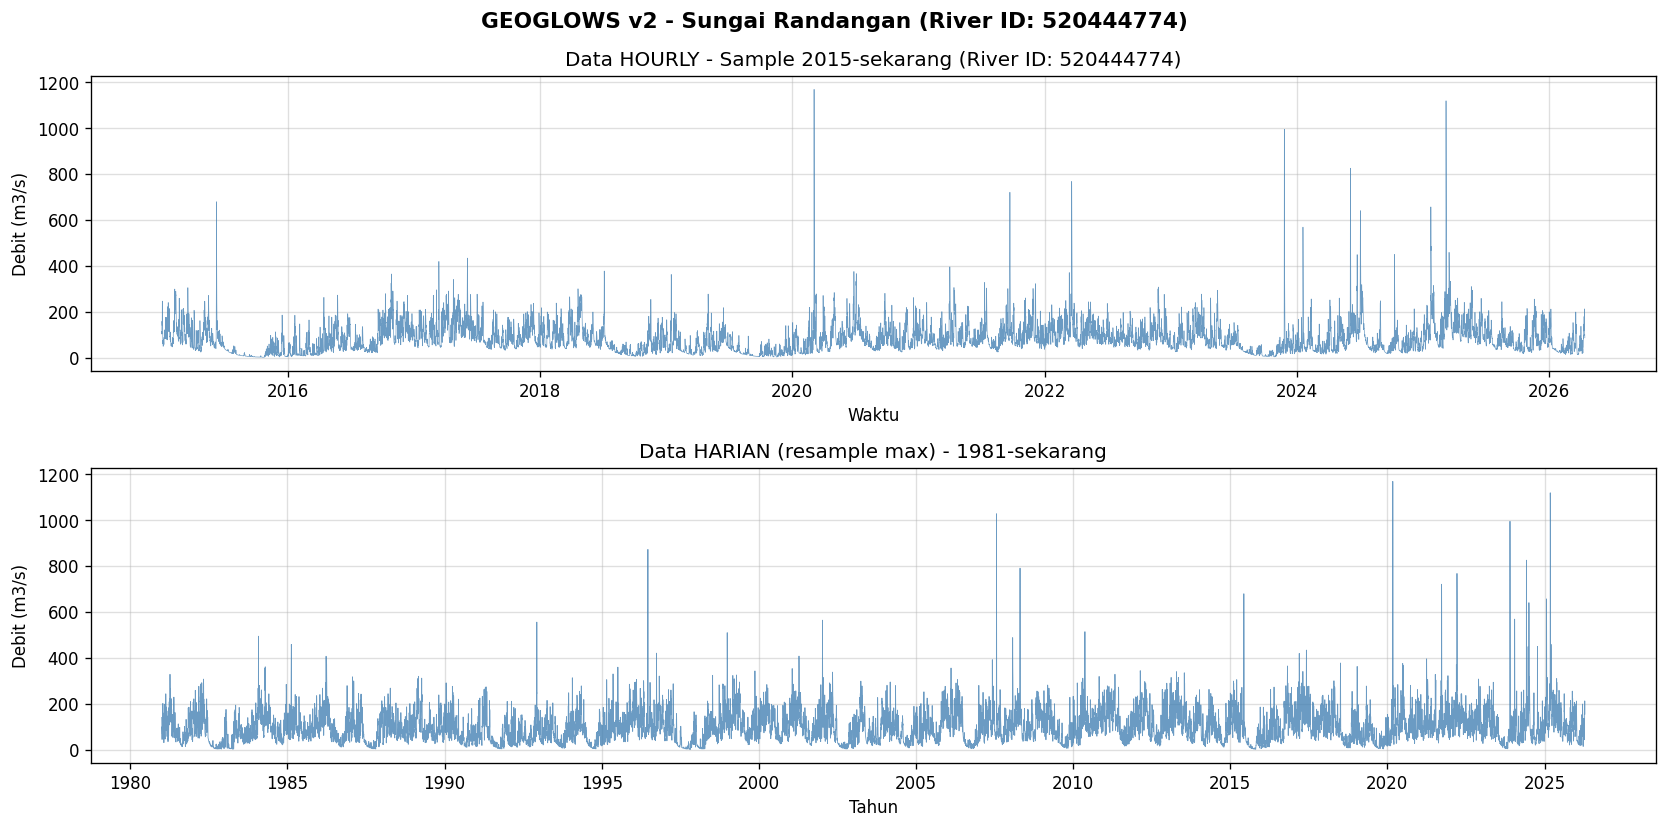

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

ax = axes[0]
sample = df_hourly['2015-01-01':]
ax.plot(sample.index, sample['Q_sim'], lw=0.4, color='steelblue', alpha=0.8)
ax.set_title(f'Data HOURLY - Sample 2015-sekarang (River ID: {RIVER_ID})')
ax.set_xlabel('Waktu')
ax.set_ylabel('Debit (m3/s)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[1]
ax.plot(retro.index, retro['Q_sim'], lw=0.5, color='steelblue', alpha=0.8)
ax.set_title(f'Data HARIAN (resample max) - {START_YEAR}-sekarang')
ax.set_xlabel('Tahun')
ax.set_ylabel('Debit (m3/s)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle(f'GEOGLOWS v2 - Sungai Randangan (River ID: {RIVER_ID})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('retro_overview.png', dpi=150)
plt.show()

## 3. Bias Correction via FDC

**Mode ungauged:** normalisasi bias musiman internal.

Ganti `HAS_OBS = True` dan upload CSV jika ada data AWLR dari BBWS Sulawesi II.

Ref: Hales et al. (2023) SABER method.

In [15]:
# Muat data AWLR jika tersedia (opsional)
# from google.colab import files
# uploaded = files.upload()
# obs = pd.read_csv('awlr_randangan.csv', parse_dates=['date'], index_col='date')
# obs.columns = ['Q_obs']
# obs = obs.resample('D').mean()
# HAS_OBS = True

HAS_OBS = False
print('Mode:', 'gauged (data AWLR)' if HAS_OBS else 'ungauged (FDC normalization internal)')

Mode: ungauged (FDC normalization internal)


In [16]:
def fdc_bc_ungauged(sim, monthly=True):
    """
    Bias correction internal untuk DAS ungauged.
    Normalisasi rasio median bulanan vs median global.
    Ref: Hales et al. (2023) doi:10.1016/j.jhydrol.2023.130279
    """
    corr = sim.copy()
    gm   = sim.median()
    if monthly:
        for mo in range(1, 13):
            msk = sim.index.month == mo
            mm  = sim[msk].median()
            if mm > 0:
                corr.loc[msk] = sim.loc[msk] * (gm / mm)
    corr = corr.clip(upper=sim.max() * 1.5)
    return corr


if HAS_OBS:
    import geoglows.bias as gb
    retro['Q_bc'] = gb.correct_historical(
        retro[['Q_sim']], obs[['Q_obs']]).values.flatten()
    print('BC GAUGED selesai')
else:
    retro['Q_bc'] = fdc_bc_ungauged(retro['Q_sim'])
    print('BC UNGAUGED selesai')

print(f'  Q_sim max : {retro.Q_sim.max():.1f} m3/s')
print(f'  Q_bc  max : {retro.Q_bc.max():.1f} m3/s')

BC UNGAUGED selesai
  Q_sim max : 1169.8 m3/s
  Q_bc  max : 1364.5 m3/s


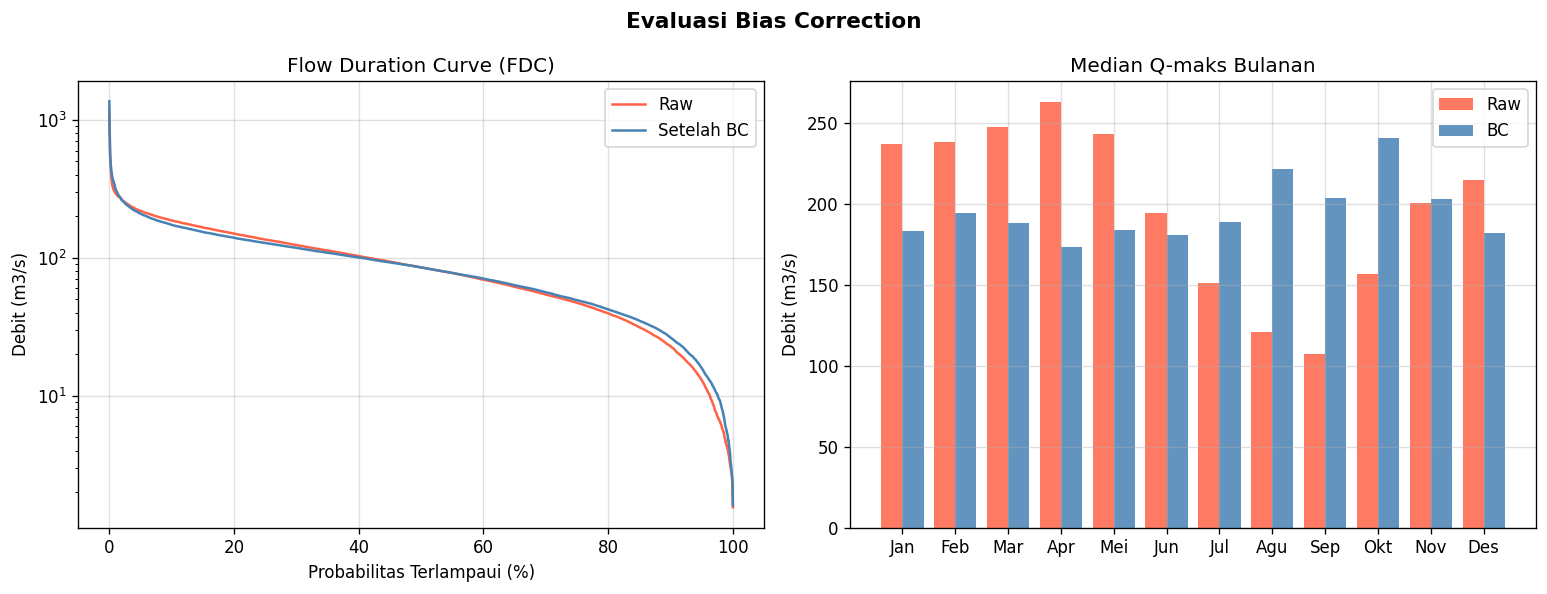

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for col, lbl, c in [('Q_sim','Raw','tomato'), ('Q_bc','Setelah BC','steelblue')]:
    sq = np.sort(retro[col].dropna().values)[::-1]
    ep = np.arange(1, len(sq)+1) / len(sq) * 100
    ax.semilogy(ep, sq, lw=1.5, label=lbl, color=c)
ax.set_xlabel('Probabilitas Terlampaui (%)')
ax.set_ylabel('Debit (m3/s)')
ax.set_title('Flow Duration Curve (FDC)')
ax.legend()

ax = axes[1]
for i, (col, lbl, c) in enumerate([('Q_sim','Raw','tomato'), ('Q_bc','BC','steelblue')]):
    mm   = retro[col].resample('ME').max()
    meds = [mm[mm.index.month == m].median() for m in range(1, 13)]
    ax.bar(np.arange(12) + (i-0.5)*0.4, meds, 0.4, label=lbl, color=c, alpha=0.85)
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
ax.set_title('Median Q-maks Bulanan')
ax.set_ylabel('Debit (m3/s)')
ax.legend()

plt.suptitle('Evaluasi Bias Correction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bc_eval.png', dpi=150)
plt.show()

## 4. Analisis Frekuensi Banjir

**Seri:** Annual Maximum Series (AMS)

**Distribusi:** Log-Pearson III · Gumbel EV1 · Log-Normal 2P

**Uji keselarasan:** Kolmogorov-Smirnov (α = 0.05)

In [19]:
ams = retro['Q_bc'].resample('YE').max().dropna()
cnt = retro['Q_bc'].resample('YE').count()
ams = ams[cnt >= 300]

log_ams = np.log10(ams.values)

print('=== ANNUAL MAXIMUM SERIES ===')
print(f'  N tahun  : {len(ams)}')
print(f'  Rentang  : {ams.index.year.min()} - {ams.index.year.max()}')
print(f'  Q min    : {ams.min():.1f} m3/s')
print(f'  Q max    : {ams.max():.1f} m3/s')
print(f'  Q mean   : {ams.mean():.1f} m3/s')
print(f'  Std dev  : {ams.std():.1f} m3/s')
print(f'  Cv       : {ams.std()/ams.mean():.3f}')
print(f'  Cs (log) : {stats.skew(log_ams):.4f}')

=== ANNUAL MAXIMUM SERIES ===
  N tahun  : 45
  Rentang  : 1981 - 2025
  Q min    : 198.9 m3/s
  Q max    : 1364.5 m3/s
  Q mean   : 451.8 m3/s
  Std dev  : 275.5 m3/s
  Cv       : 0.610
  Cs (log) : 0.7836


In [21]:
return_periods = [2, 5, 10, 25, 50, 100, 200, 500]
ex_probs       = [1 - 1/T for T in return_periods]
results        = {}

lp3_p = pearson3.fit(log_ams)
results['Log-Pearson III'] = {
    'Q'   : [10**pearson3.ppf(p, *lp3_p) for p in ex_probs],
    'KS_D': stats.kstest(log_ams, 'pearson3', args=lp3_p).statistic,
    'KS_p': stats.kstest(log_ams, 'pearson3', args=lp3_p).pvalue}

gum_p = gumbel_r.fit(ams.values)
results['Gumbel'] = {
    'Q'   : [gumbel_r.ppf(p, *gum_p) for p in ex_probs],
    'KS_D': stats.kstest(ams.values, 'gumbel_r', args=gum_p).statistic,
    'KS_p': stats.kstest(ams.values, 'gumbel_r', args=gum_p).pvalue}

ln_p = lognorm.fit(ams.values, floc=0)
results['Log-Normal'] = {
    'Q'   : [lognorm.ppf(p, *ln_p) for p in ex_probs],
    'KS_D': stats.kstest(ams.values, 'lognorm', args=ln_p).statistic,
    'KS_p': stats.kstest(ams.values, 'lognorm', args=ln_p).pvalue}

df_freq = pd.DataFrame(
    {d: r['Q'] for d, r in results.items()},
    index=[f'T={T}' for T in return_periods]
).round(1)

print('=== DEBIT RANCANGAN (m3/s) ===')
print(df_freq.to_string())
print()
print(f'{"Distribusi":<20} {"D-stat":>8} {"p-value":>10} {"Keputusan":>10}')
print('-'*53)
for d, r in results.items():
    ok = 'DITERIMA' if r['KS_p'] > 0.05 else 'DITOLAK'
    print(f'{d:<20} {r["KS_D"]:>8.4f} {r["KS_p"]:>10.4f} {ok:>10}')

best = max(results, key=lambda k: results[k]['KS_p'])
print(f'\nDistribusi terpilih: {best}  (p = {results[best]["KS_p"]:.4f})')

=== DEBIT RANCANGAN (m3/s) ===
       Log-Pearson III  Gumbel  Log-Normal
T=2              344.3   401.3       393.6
T=5              571.3   583.7       597.8
T=10             812.7   704.5       743.7
T=25            1271.1   857.1       938.8
T=50            1767.3   970.3      1091.3
T=100           2444.6  1082.7      1249.5
T=200           3368.3  1194.7      1414.3
T=500           5122.0  1342.4      1643.4

Distribusi             D-stat    p-value  Keputusan
-----------------------------------------------------
Log-Pearson III        0.0617     0.9914   DITERIMA
Gumbel                 0.1239     0.4577   DITERIMA
Log-Normal             0.1027     0.6911   DITERIMA

Distribusi terpilih: Log-Pearson III  (p = 0.9914)


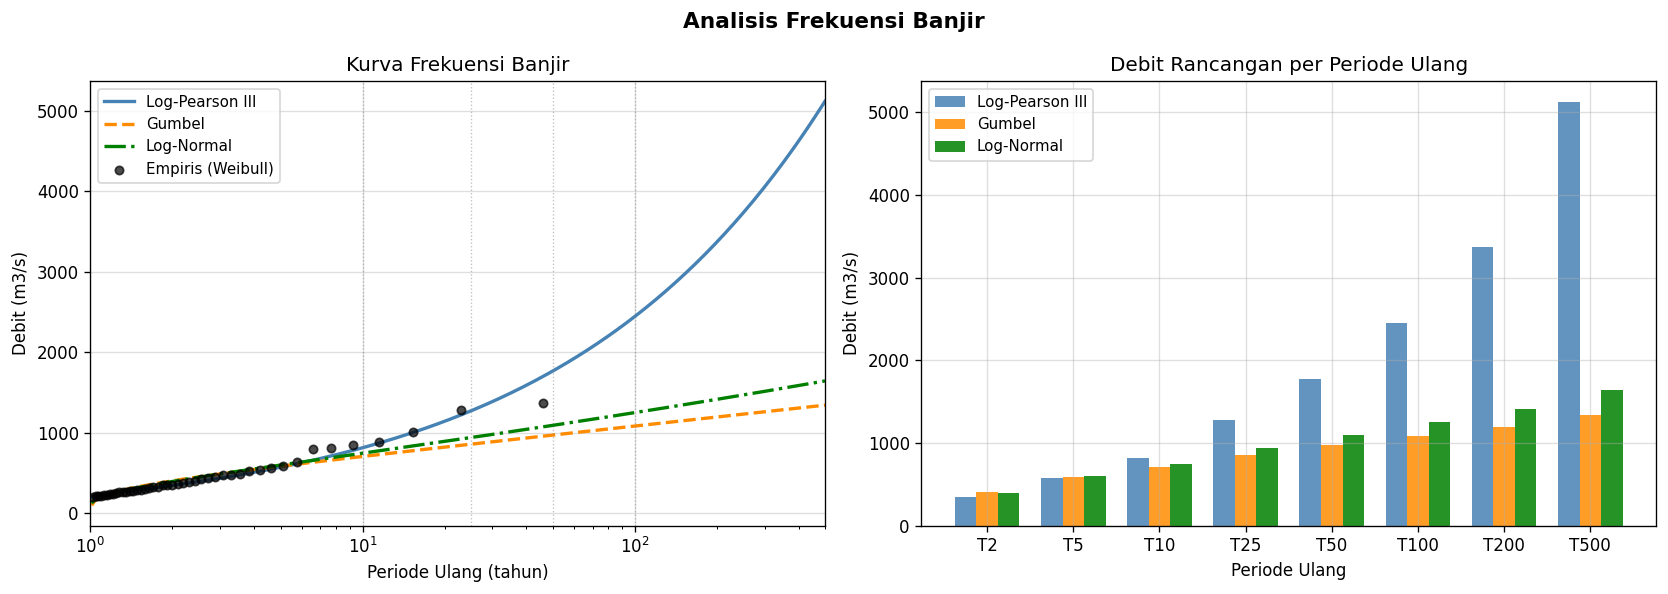

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols = {'Log-Pearson III':'steelblue', 'Gumbel':'darkorange', 'Log-Normal':'green'}
lss  = {'Log-Pearson III':'-',         'Gumbel':'--',          'Log-Normal':'-.'}

ax = axes[0]
Ts = np.logspace(np.log10(1.01), np.log10(500), 300)
ps = [1 - 1/T for T in Ts]
for dist in results:
    if dist == 'Log-Pearson III': qs = [10**pearson3.ppf(p, *lp3_p) for p in ps]
    elif dist == 'Gumbel'       : qs = [gumbel_r.ppf(p, *gum_p) for p in ps]
    else                        : qs = [lognorm.ppf(p, *ln_p) for p in ps]
    ax.semilogx(Ts, qs, lw=2, label=dist, color=cols[dist], linestyle=lss[dist])

ams_s = np.sort(ams.values); n = len(ams_s)
T_emp = (n+1) / (n+1 - np.arange(1, n+1))
ax.scatter(T_emp, ams_s, c='black', zorder=5, s=25, label='Empiris (Weibull)', alpha=0.7)
for T in [10, 25, 50, 100]:
    ax.axvline(T, color='gray', lw=0.8, ls=':', alpha=0.5)
ax.set_xlabel('Periode Ulang (tahun)')
ax.set_ylabel('Debit (m3/s)')
ax.set_title('Kurva Frekuensi Banjir')
ax.legend(fontsize=9)
ax.set_xlim([1, 500])

ax = axes[1]
x = np.arange(len(return_periods))
for i, (d, r) in enumerate(results.items()):
    ax.bar(x + (i-1)*0.25, r['Q'], 0.25, label=d,
           color=list(cols.values())[i], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'T{T}' for T in return_periods])
ax.set_xlabel('Periode Ulang')
ax.set_ylabel('Debit (m3/s)')
ax.set_title('Debit Rancangan per Periode Ulang')
ax.legend(fontsize=9)

plt.suptitle('Analisis Frekuensi Banjir',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('freq_analysis.png', dpi=150)
plt.show()

## 5. Hidrograf Desain

Template diambil dari data **hourly** event terbesar untuk bentuk hidrograf yang lebih halus dan realistis sebagai input HEC-RAS.

In [23]:
def find_peaks(s, n=5, gap_days=30):
    """Identifikasi n event puncak terpisah minimal gap_days."""
    pks = []
    for idx in s.sort_values(ascending=False).index:
        if not pks or all(abs((idx-p).days) >= gap_days for p in pks):
            pks.append(idx)
        if len(pks) >= n:
            break
    return pks

def get_event_hourly(peak_date, before_days=5, after_days=15):
    """Ekstrak hidrograf hourly di sekitar tanggal puncak harian."""
    start = pd.Timestamp(peak_date) - pd.Timedelta(days=before_days)
    end   = pd.Timestamp(peak_date) + pd.Timedelta(days=after_days)
    ev    = df_hourly.loc[start:end, 'Q_sim'].copy()
    ev.index = (ev.index - ev.index[0]).total_seconds() / 3600  # jam relatif
    return ev

top5 = find_peaks(retro['Q_bc'], n=5, gap_days=30)

print('Top 5 Event Banjir:')
print(f'{"No":>3}  {"Tanggal":>12}  {"Q_bc harian (m3/s)":>20}')
print('-'*42)
for i, pk in enumerate(top5):
    print(f'{i+1:>3}  {str(pk.date()):>12}  {retro.loc[pk, "Q_bc"]:>20.1f}')

Top 5 Event Banjir:
 No       Tanggal    Q_bc harian (m3/s)
------------------------------------------
  1    2021-09-22                1364.5
  2    2007-07-25                1284.3
  3    2023-11-26                1006.4
  4    2020-03-04                 890.0
  5    2025-03-08                 852.1


In [24]:
# ================================================================
# SESUAIKAN PERIODE ULANG DESAIN DI SINI
T_design = 100   # pilihan: 2, 5, 10, 25, 50, 100, 200, 500
# ================================================================

T_idx    = return_periods.index(T_design)
Q_design = results[best]['Q'][T_idx]

tmpl      = get_event_hourly(top5[0])
scale     = Q_design / tmpl.max()
dh_hourly = (tmpl * scale).clip(lower=0)

print(f'Distribusi terpilih : {best}')
print(f'Q rancangan T{T_design}   : {Q_design:.1f} m3/s')
print(f'Template event      : {top5[0].date()} (Qpeak={tmpl.max():.1f} m3/s)')
print(f'Scale factor        : {scale:.3f}')
print(f'Qpeak desain        : {dh_hourly.max():.1f} m3/s')
print(f'Durasi              : {len(dh_hourly)} jam ({len(dh_hourly)/24:.1f} hari)')

Distribusi terpilih : Log-Pearson III
Q rancangan T100   : 2444.6 m3/s
Template event      : 2021-09-22 (Qpeak=721.2 m3/s)
Scale factor        : 3.390
Qpeak desain        : 2444.6 m3/s
Durasi              : 481 jam (20.0 hari)


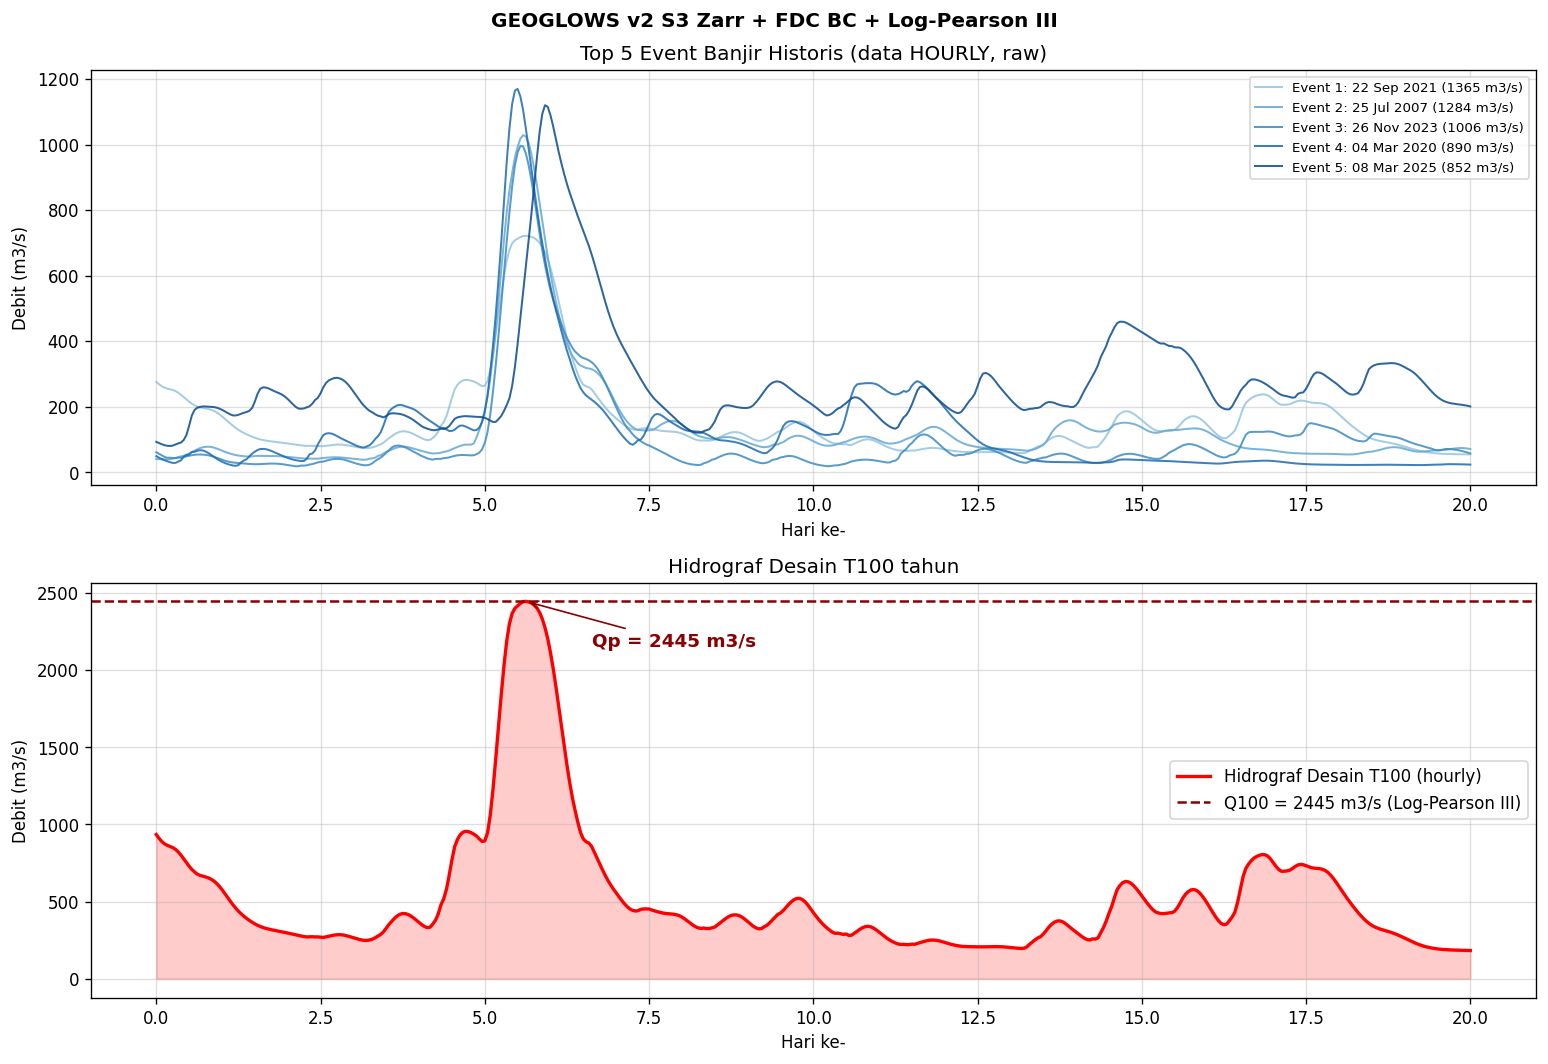

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Panel atas: 5 event historis (hourly)
ax = axes[0]
cm = plt.cm.Blues(np.linspace(0.4, 0.9, 5))
for i, pk in enumerate(top5):
    ev = get_event_hourly(pk)
    ax.plot(ev.index/24, ev.values, lw=1.2, color=cm[i], alpha=0.85,
            label=f'Event {i+1}: {pk.strftime("%d %b %Y")} ({retro.loc[pk,"Q_bc"]:.0f} m3/s)')
ax.set_xlabel('Hari ke-')
ax.set_ylabel('Debit (m3/s)')
ax.set_title('Top 5 Event Banjir Historis (data HOURLY, raw)')
ax.legend(fontsize=8, loc='upper right')

# Panel bawah: hidrograf desain
ax = axes[1]
t_days = dh_hourly.index / 24
ax.fill_between(t_days, dh_hourly.values, alpha=0.2, color='red')
ax.plot(t_days, dh_hourly.values, lw=2, color='red',
        label=f'Hidrograf Desain T{T_design} (hourly)')
ax.axhline(Q_design, color='darkred', ls='--', lw=1.5,
           label=f'Q{T_design} = {Q_design:.0f} m3/s ({best})')
pk_hr = dh_hourly.idxmax()
ax.annotate(
    f'Qp = {dh_hourly.max():.0f} m3/s',
    xy=(pk_hr/24, dh_hourly.max()),
    xytext=(pk_hr/24 + 1, dh_hourly.max()*0.88),
    arrowprops=dict(arrowstyle='->', color='darkred'),
    fontsize=11, color='darkred', fontweight='bold')
ax.set_xlabel('Hari ke-')
ax.set_ylabel('Debit (m3/s)')
ax.set_title(f'Hidrograf Desain T{T_design} tahun')
ax.legend(fontsize=10)

plt.suptitle(f'GEOGLOWS v2 S3 Zarr + FDC BC + {best}',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'hydrograph_T{T_design}.png', dpi=150)
plt.show()

## 5b. Ekstraksi Data Debit Hourly per Event Banjir

Sel ini mengekstrak time series debit hourly untuk setiap event banjir ke file CSV terpisah,
siap digunakan sebagai input simulasi hidraulik (HEC-RAS, LISFLODD-FP, dll).

In [30]:
# ================================================================
# KONFIGURASI EKSTRAKSI EVENT
# ================================================================
BEFORE_DAYS = 3    # hari sebelum puncak yang diambil
AFTER_DAYS  = 10   # hari sesudah puncak yang diambil

# Pilih event yang ingin diekstrak (default: semua top5)
# Ubah ke list index tertentu jika tidak semua, misal: [0, 2]
EVENTS_TO_EXTRACT = list(range(len(top5)))
# ================================================================

print(f'Konfigurasi ekstraksi:')
print(f'  Window  : -{BEFORE_DAYS} hari sebelum puncak, +{AFTER_DAYS} hari sesudah')
print(f'  Events  : {len(EVENTS_TO_EXTRACT)} event')
print()

event_data = {}

for i in EVENTS_TO_EXTRACT:
    pk   = top5[i]
    name = f'Event{i+1}_{pk.strftime("%Y%m%d")}'

    # Window waktu
    t_start = pd.Timestamp(pk) - pd.Timedelta(days=BEFORE_DAYS)
    t_end   = pd.Timestamp(pk) + pd.Timedelta(days=AFTER_DAYS)

    # Potong data hourly (raw, sebelum BC)
    ev_raw = df_hourly.loc[t_start:t_end, 'Q_sim'].copy()

    # Buat DataFrame lengkap
    ev_df = pd.DataFrame({
        'datetime'   : ev_raw.index,
        'time_hours' : (ev_raw.index - ev_raw.index[0]).total_seconds() / 3600,
        'Q_raw_m3s'  : ev_raw.values.round(3),
    })

    # Tambahkan kolom Q bias-corrected (interpolasi dari retro harian ke hourly)
    # dengan faktor koreksi harian diterapkan ke setiap jam pada hari yang sama
    bc_factors = (retro['Q_bc'] / retro['Q_sim'].replace(0, np.nan)).dropna()
    hourly_factor = ev_df['datetime'].apply(
        lambda t: bc_factors.get(t.normalize(), 1.0)
    )
    ev_df['Q_bc_m3s'] = (ev_df['Q_raw_m3s'] * hourly_factor).round(3).clip(lower=0)

    event_data[name] = ev_df

    # Info
    print(f'Event {i+1}: {pk.date()}')
    print(f'  Window    : {t_start.date()} s/d {t_end.date()}')
    print(f'  N baris   : {len(ev_df)} jam')
    print(f'  Q_raw max : {ev_df.Q_raw_m3s.max():.1f} m3/s')
    print(f'  Q_bc  max : {ev_df.Q_bc_m3s.max():.1f} m3/s')
    print()

Konfigurasi ekstraksi:
  Window  : -3 hari sebelum puncak, +10 hari sesudah
  Events  : 5 event

Event 1: 2021-09-22
  Window    : 2021-09-19 s/d 2021-10-02
  N baris   : 313 jam
  Q_raw max : 721.2 m3/s
  Q_bc  max : 1364.5 m3/s

Event 2: 2007-07-25
  Window    : 2007-07-22 s/d 2007-08-04
  N baris   : 313 jam
  Q_raw max : 1028.6 m3/s
  Q_bc  max : 1284.3 m3/s

Event 3: 2023-11-26
  Window    : 2023-11-23 s/d 2023-12-06
  N baris   : 313 jam
  Q_raw max : 995.8 m3/s
  Q_bc  max : 1006.4 m3/s

Event 4: 2020-03-04
  Window    : 2020-03-01 s/d 2020-03-14
  N baris   : 313 jam
  Q_raw max : 1169.8 m3/s
  Q_bc  max : 890.0 m3/s

Event 5: 2025-03-08
  Window    : 2025-03-05 s/d 2025-03-18
  N baris   : 313 jam
  Q_raw max : 1120.0 m3/s
  Q_bc  max : 852.1 m3/s



In [32]:
# ================================================================
# EXPORT KE CSV (satu file per event)
# ================================================================
for name, ev_df in event_data.items():
    fname = f'hourly_{name}.csv'
    ev_df.to_csv(fname, index=False)
    print(f'Tersimpan: {fname}  ({len(ev_df)} baris)')

# ================================================================
# EXPORT KE SATU FILE GABUNGAN (semua event, long format)
# ================================================================
dfs = []
for name, ev_df in event_data.items():
    tmp = ev_df.copy()
    tmp.insert(0, 'event', name)
    dfs.append(tmp)

df_all = pd.concat(dfs, ignore_index=True)
df_all.to_csv('hourly_all_events.csv', index=False)
print(f'\nGabungan  : hourly_all_events.csv  ({len(df_all)} baris total)')

Tersimpan: hourly_Event1_20210922.csv  (313 baris)
Tersimpan: hourly_Event2_20070725.csv  (313 baris)
Tersimpan: hourly_Event3_20231126.csv  (313 baris)
Tersimpan: hourly_Event4_20200304.csv  (313 baris)
Tersimpan: hourly_Event5_20250308.csv  (313 baris)

Gabungan  : hourly_all_events.csv  (1565 baris total)


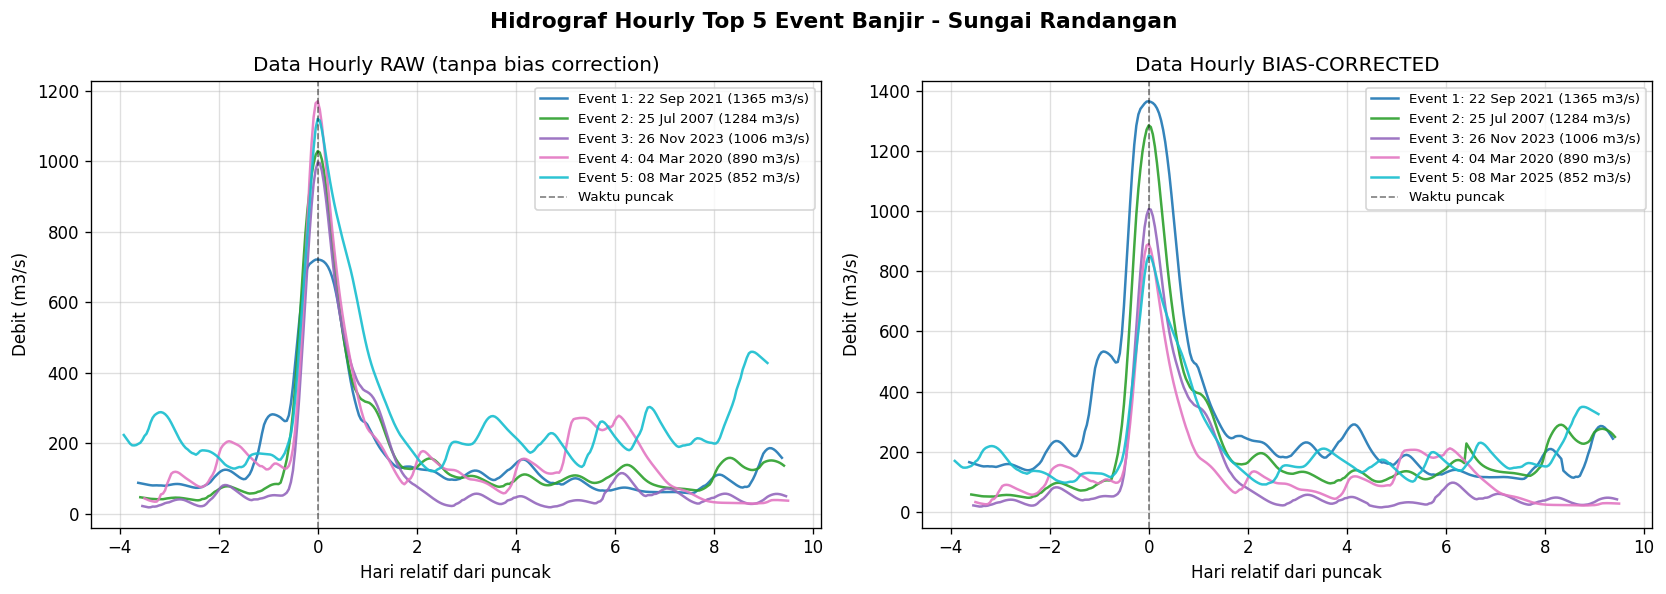

In [33]:
# ================================================================
# PLOT OVERLAY SEMUA EVENT (sumbu waktu relatif)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = plt.cm.tab10(np.linspace(0, 0.9, len(event_data)))

for ax, col, title in zip(
    axes,
    ['Q_raw_m3s', 'Q_bc_m3s'],
    ['Data Hourly RAW (tanpa bias correction)', 'Data Hourly BIAS-CORRECTED']
):
    for j, (name, ev_df) in enumerate(event_data.items()):
        pk_idx = top5[j]
        label  = f'Event {j+1}: {pk_idx.strftime("%d %b %Y")} ({retro.loc[pk_idx,"Q_bc"]:.0f} m3/s)'
        # Waktu relatif dari puncak (bukan dari awal window)
        pk_hour = ev_df.loc[ev_df[col].idxmax(), 'time_hours']
        t_rel   = ev_df['time_hours'] - pk_hour
        ax.plot(t_rel / 24, ev_df[col], lw=1.5, color=cm[j], label=label, alpha=0.9)

    ax.axvline(0, color='black', lw=1, ls='--', alpha=0.5, label='Waktu puncak')
    ax.set_xlabel('Hari relatif dari puncak')
    ax.set_ylabel('Debit (m3/s)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Hidrograf Hourly Top 5 Event Banjir',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hourly_events_overlay.png', dpi=150)
plt.show()

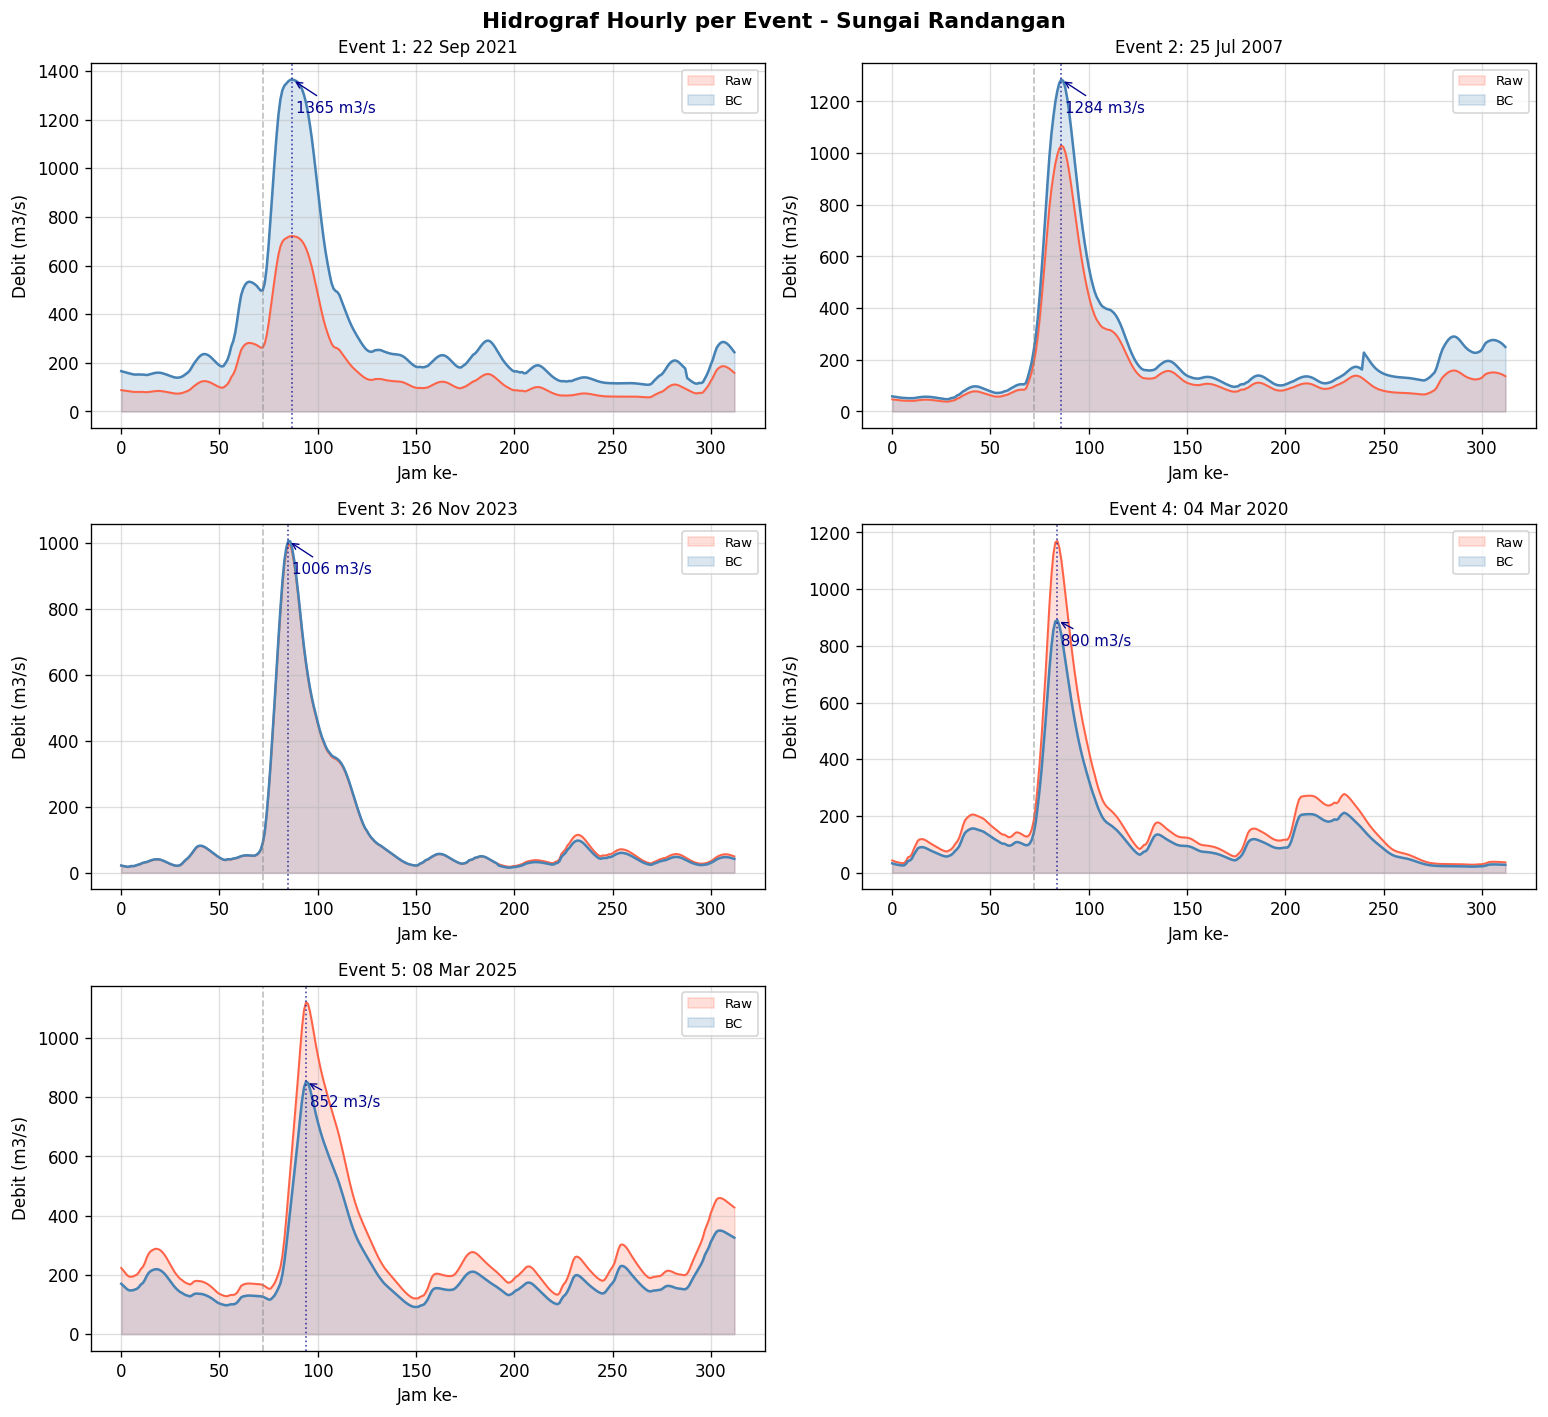

In [34]:
# ================================================================
# PLOT INDIVIDUAL TIAP EVENT (subplot grid)
# ================================================================
n_ev = len(event_data)
ncols = 2
nrows = (n_ev + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4*nrows))
axes = axes.flatten()

for j, (name, ev_df) in enumerate(event_data.items()):
    ax  = axes[j]
    pk  = top5[j]
    t_h = ev_df['time_hours']

    ax.fill_between(t_h, ev_df['Q_raw_m3s'], alpha=0.2, color='tomato', label='Raw')
    ax.plot(t_h, ev_df['Q_raw_m3s'], lw=1.2, color='tomato')
    ax.fill_between(t_h, ev_df['Q_bc_m3s'], alpha=0.2, color='steelblue', label='BC')
    ax.plot(t_h, ev_df['Q_bc_m3s'], lw=1.5, color='steelblue')

    # Tandai puncak
    pk_t = ev_df.loc[ev_df['Q_bc_m3s'].idxmax(), 'time_hours']
    pk_q = ev_df['Q_bc_m3s'].max()
    ax.axvline(pk_t, color='darkblue', lw=1, ls=':', alpha=0.7)
    ax.annotate(f'{pk_q:.0f} m3/s', xy=(pk_t, pk_q),
                xytext=(pk_t + 2, pk_q * 0.9),
                fontsize=9, color='darkblue',
                arrowprops=dict(arrowstyle='->', color='darkblue', lw=0.8))

    # Tandai posisi puncak harian di sumbu x
    pk_hour_in_window = (pd.Timestamp(pk) - (pd.Timestamp(pk) - pd.Timedelta(days=BEFORE_DAYS))).total_seconds()/3600
    ax.axvline(pk_hour_in_window, color='gray', lw=1, ls='--', alpha=0.5)

    ax.set_title(f'Event {j+1}: {pk.strftime("%d %b %Y")}', fontsize=10)
    ax.set_xlabel('Jam ke-')
    ax.set_ylabel('Debit (m3/s)')
    ax.legend(fontsize=8)

# Sembunyikan subplot kosong jika ganjil
for j in range(n_ev, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Hidrograf Hourly per Event - Sungai Randangan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hourly_events_individual.png', dpi=150)
plt.show()

In [35]:
# ================================================================
# RINGKASAN KARAKTERISTIK TIAP EVENT
# ================================================================
print('=== KARAKTERISTIK EVENT BANJIR (hourly) ===')
print(f'{"Event":<10} {"Tanggal":>12} {"Qpeak_bc":>10} {"Time_to_peak":>14} {"Volume_bc":>12}')
print(f'{"":10} {"":12} {"(m3/s)":>10} {"(jam)":>14} {"(juta m3)":>12}')
print('-'*65)

for j, (name, ev_df) in enumerate(event_data.items()):
    pk        = top5[j]
    qpeak     = ev_df['Q_bc_m3s'].max()
    t_peak    = ev_df.loc[ev_df['Q_bc_m3s'].idxmax(), 'time_hours']
    # Volume = integral Q dt (trapesoid), dt = 1 jam = 3600 detik
    volume_m3 = np.trapz(ev_df['Q_bc_m3s'].values, dx=3600)
    volume_jt = volume_m3 / 1e6

    print(f'Event {j+1:<4} {str(pk.date()):>12} {qpeak:>10.1f} {t_peak:>14.1f} {volume_jt:>12.2f}')

print()
print('Catatan:')
print('  Qpeak_bc  = debit puncak bias-corrected')
print('  Time_to_peak = jam dari awal window ke puncak')
print('  Volume_bc = volume total aliran selama window (integral trapezoidal)')

=== KARAKTERISTIK EVENT BANJIR (hourly) ===
Event           Tanggal   Qpeak_bc   Time_to_peak    Volume_bc
                            (m3/s)          (jam)    (juta m3)
-----------------------------------------------------------------
Event 1      2021-09-22     1364.5           87.0       341.75
Event 2      2007-07-25     1284.3           86.0       249.18
Event 3      2023-11-26     1006.4           85.0       133.68
Event 4      2020-03-04      890.0           84.0       158.24
Event 5      2025-03-08      852.1           94.0       243.25

Catatan:
  Qpeak_bc  = debit puncak bias-corrected
  Time_to_peak = jam dari awal window ke puncak
  Volume_bc = volume total aliran selama window (integral trapezoidal)


## 6. Export HEC-RAS / LISFLOOD-FP

In [36]:
# CSV resolusi jam
pd.DataFrame({
    'time_hours': dh_hourly.index,
    'Q_m3s'     : dh_hourly.values.round(3)
}).to_csv(f'hydrograph_T{T_design}.csv', index=False)
print(f'CSV : hydrograph_T{T_design}.csv  ({len(dh_hourly)} baris hourly)')

# HEC-RAS plain text
lines = [
    f'# Hidrograf Desain T{T_design} tahun',
    f'# Distribusi     : {best}',
    f'# Q_peak         : {Q_design:.0f} m3/s',
    f'# River ID       : {RIVER_ID}',
    f'# Sumber data    : GEOGLOWS v2 S3 Zarr (ERA5, hourly) + FDC BC',
    f'# Template event : {top5[0].date()}',
    f'# Ketidakpastian : +/-30-50% (ungauged, tanpa AWLR)',
    '#',
    '# Time(hr)  Flow(m3/s)'
]
for t, q in zip(dh_hourly.index, dh_hourly.values):
    lines.append(f'{t:10.1f}  {q:10.3f}')
with open(f'HECRAS_T{T_design}.txt', 'w') as f:
    f.write('\n'.join(lines))
print(f'HEC-RAS : HECRAS_T{T_design}.txt')

# Tabel semua T
df_freq.to_csv('debit_rancangan.csv')
print('Tabel   : debit_rancangan.csv')

print(f'''
=== RINGKASAN HASIL ===

  River ID    : {RIVER_ID}
  Data        : GEOGLOWS v2 S3 Zarr hourly (ERA5) 1940-sekarang
  BC mode     : {"gauged" if HAS_OBS else "ungauged FDC normalization"}
  Distribusi  : {best}
  T desain    : {T_design} tahun
  Q_peak      : {Q_design:.0f} m3/s
  Resolusi HG : hourly
''')

CSV : hydrograph_T100.csv  (481 baris hourly)
HEC-RAS : HECRAS_T100.txt
Tabel   : debit_rancangan.csv

=== RINGKASAN HASIL ===
  River ID    : 520444774
  Data        : GEOGLOWS v2 S3 Zarr hourly (ERA5) 1940-sekarang
  BC mode     : ungauged FDC normalization
  Distribusi  : Log-Pearson III
  T desain    : 100 tahun
  Q_peak      : 2445 m3/s
  Resolusi HG : hourly



## 7. Template Metodologi

---

**Data Debit**

Data debit diperoleh dari simulasi retrospektif GEOGLOWS River Forecast System Version 2 (RFS v2) berbasis reanalisis ERA5 ECMWF. Data diakses dari bucket AWS S3 (`s3://geoglows-v2/retrospective/hourly.zarr`) dalam resolusi hourly, mencakup periode April 1940 (setelah spin-up model) hingga saat ini. River ID yang digunakan adalah 520444774, merepresentasikan Sungai Randangan, Kabupaten Pohuwato, Gorontalo.

**Praproses**

Tiga bulan pertama simulasi (Januari–Maret) dibuang untuk menghilangkan efek spin-up model. Data hourly diagregasi ke resolusi harian menggunakan nilai maksimum harian (`resample('D').max()`) guna mempertahankan puncak debit intra-harian.

**Koreksi Bias**

Koreksi bias dilakukan secara internal menggunakan normalisasi FDC bulanan yang menyelaraskan distribusi debit tiap bulan terhadap median global untuk mengurangi bias musiman sistematis (Hales et al., 2023). Ketidakpastian nilai absolut diestimasi ±30–50%.

**Analisis Frekuensi**

Annual Maximum Series (AMS) dianalisis menggunakan Log-Pearson III, Gumbel EV1, dan Log-Normal 2P. Distribusi terpilih berdasarkan uji Kolmogorov-Smirnov (α = 0,05). Hidrograf desain dihasilkan dengan scaling event historis terbesar (resolusi hourly) ke debit puncak rancangan.

**Referensi**
- Hales et al. (2022). J. Flood Risk Management. doi:10.1111/jfr3.12859
- Hales et al. (2023). J. Hydrology, 626, 130279. doi:10.1016/j.jhydrol.2023.130279
- GEOGLOWS v2. AWS Open Data. https://registry.opendata.aws/geoglows-v2

---